# K-Means

- Images 32x32 RGB, six formes (`bar`, `circle`, `cross`, `square`, `star`, `triangle`) sur fond sombre bruité ; couleur, taille, position et rotation tirées aléatoirement.
- Approche générale :
  - `encode(X)` : indice du centroïde le plus proche, le code latent discret.
  - `decode(latent)` : chaque code redevient son centroïde, la reconstruction.
  - `get_codebook()` : les K centroïdes, le dictionnaire partagé.
- Fil conducteur expérimental : faire varier K et le nombre d'initialisations, mesurer l'effet sur chaque angle.

In [1]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report, Latent
from src.dataset import load_shapes_dataset
from src.helper import extract_full_dataset

rng = np.random.default_rng(0)
%matplotlib inline

## 1. Chargement et préparation des données

- `ImageFolder` sur le sous-dossier `train` (la racine détecterait `['train', 'validation']` comme classes).
- `extract_full_dataset` rassemble tous les batches ; graine torch fixée pour un mélange reproductible.
- Sous-ensemble de N = 10 000 images : suffisant pour l'étude, assez léger pour ré-exécuter vite.
- Chaque image `(3, 32, 32)` aplatie à la volée en 3072 composantes ; `ToTensor` a déjà ramené les pixels dans `[0, 1]`, distance euclidienne homogène.

In [2]:
torch.manual_seed(0)
dataloader = load_shapes_dataset(data_dir="data/shapes_hard_color/train", batch_size=4096, shuffle=True)
images, shape_labels = extract_full_dataset(dataloader)

class_names = list(dataloader.dataset.classes)

N = 10000
X = images[:N].flatten(start_dim=1).numpy().astype(np.float32)
y = shape_labels[:N].numpy()


def as_image(vec):
    """Reshape a flat pixel vector back to an (H, W, C) RGB image for display."""
    return np.clip(vec, 0.0, 1.0).reshape(3, 32, 32).transpose(1, 2, 0)


print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("formes :", class_names)
print("effectifs par forme :", np.bincount(y).tolist())

X: (10000, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
formes : ['bar', 'circle', 'cross', 'square', 'star', 'triangle']
effectifs par forme : [1610, 1691, 1686, 1656, 1726, 1631]


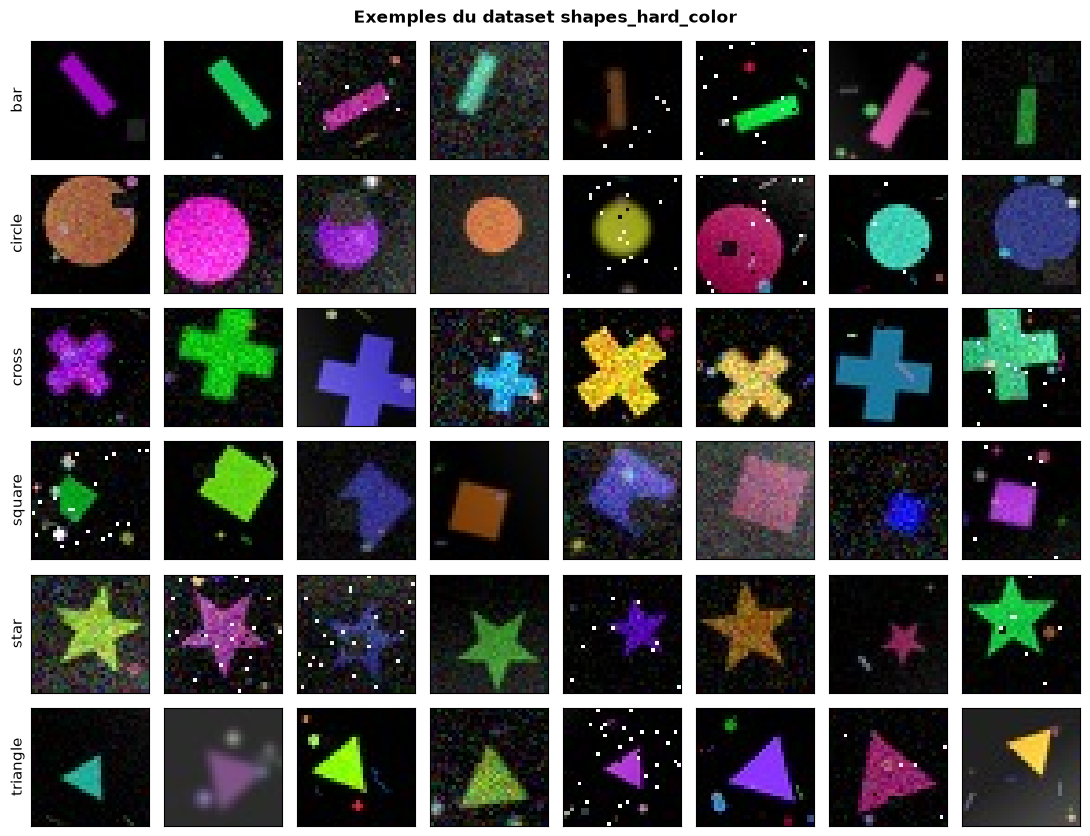

In [3]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for r in range(6):
    picks = rng.choice(np.where(y == r)[0], size=8, replace=False)
    for c in range(8):
        axes[r, c].imshow(as_image(X[picks[c]]))
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(class_names[r], fontsize=11)
fig.suptitle("Exemples du dataset shapes_hard_color", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Entraînement de K-Means

- Modèle principal à **k = 6**, une forme par cluster.
- K-Means minimise l'inertie (somme des distances au carré des points à leur centroïde) mais peut tomber dans un minimum local selon l'initialisation.
- `n_init` lance plusieurs départs indépendants via implem k-means++ et conserve le meilleur ; réglé à 10 sur le modèle principal.
- On entraîne une fois toutes les valeurs de K de `[3, 6, 64, 128, 256, 512]`. Grands K coûteux : `n_init` petit (1-2) et `max_iter` modéré pour tenir le runtime.

In [4]:
import pickle

K_VALUES = [3, 6, 64, 128, 256, 512]
# n_init / max_iter par K : grand K coûteux -> moins d'initialisations et d'itérations
FIT_CONFIG = {3: (10, 100), 6: (10, 100), 64: (2, 60), 128: (2, 50), 256: (1, 50), 512: (1, 40)}

CACHE_PATH = Path("artifacts/kmeans_cache.pkl")
CACHE_PATH.parent.mkdir(exist_ok=True)


def load_cache():
    if CACHE_PATH.exists():
        try:
            with open(CACHE_PATH, "rb") as f:
                return pickle.load(f)
        except Exception:
            pass
    return {}


def save_cache(cache):
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(cache, f)


cache = load_cache()
models = cache.get("models", {})

# On ne refit que les K manquants, puis on met le cache à jour
for k in K_VALUES:
    if k not in models:
        n_init, max_iter = FIT_CONFIG[k]
        models[k] = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter, random_state=0).fit(X)
cache["models"] = models
save_cache(cache)

kmeans = models[6]  # modèle principal (n_init = 10)

for k in K_VALUES:
    m = models[k]
    print(f"k = {k:3d}  |  n_init = {FIT_CONFIG[k][0]:2d}  |  inertie = {m.inertia_:11,.0f}  |  itérations = {m.n_iter_}")

k =   3  |  n_init = 10  |  inertie =     924,911  |  itérations = 40
k =   6  |  n_init = 10  |  inertie =     851,051  |  itérations = 30
k =  64  |  n_init =  2  |  inertie =     625,391  |  itérations = 60
k = 128  |  n_init =  2  |  inertie =     584,699  |  itérations = 40
k = 256  |  n_init =  1  |  inertie =     545,872  |  itérations = 45
k = 512  |  n_init =  1  |  inertie =     501,963  |  itérations = 29


### Combien d'initialisations ?

- On relance k = 6 depuis dix graines, une seule initialisation chacune, et on observe la dispersion des inerties.
- Courbe "gain apporté par n_init" : inertie du meilleur des n premiers départs, en fonction de n.
- Le meilleur se stabilise vite : k-means++ place déjà des centres bien répartis, chaque départ tombe dans un bassin d'inertie voisin.

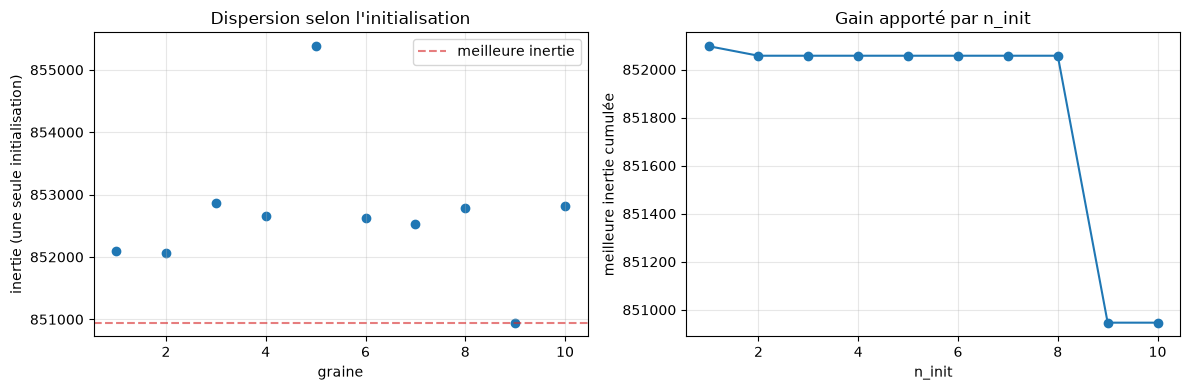

Écart pire / meilleure initialisation : 0.52%
Gain du 1er au 10e départ            : 0.14%


In [5]:
if "single_inertias" in cache:
    single_inertias = cache["single_inertias"]
else:
    single_inertias = np.array([
        KMeans(n_clusters=6, n_init=1, max_iter=100, random_state=s).fit(X).inertia_
        for s in range(10)
    ])
    cache["single_inertias"] = single_inertias
    save_cache(cache)

best_so_far = np.minimum.accumulate(single_inertias)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(range(1, 11), single_inertias, color="tab:blue")
ax1.axhline(single_inertias.min(), color="tab:red", linestyle="--", alpha=0.6, label="meilleure inertie")
ax1.set_xlabel("graine")
ax1.set_ylabel("inertie (une seule initialisation)")
ax1.set_title("Dispersion selon l'initialisation")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, 11), best_so_far, "o-")
ax2.set_xlabel("n_init")
ax2.set_ylabel("meilleure inertie cumulée")
ax2.set_title("Gain apporté par n_init")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

spread = (single_inertias.max() - single_inertias.min()) / single_inertias.min()
gain = (best_so_far[0] - best_so_far[-1]) / best_so_far[0]
print(f"Écart pire / meilleure initialisation : {spread:.2%}")
print(f"Gain du 1er au 10e départ            : {gain:.2%}")

- Écart pire / meilleure initialisation autour de 0.5%, gain du 1er au 10e départ autour de 0.1% : marginal.
- On garde `n_init = 10` sur le modèle principal, le surcoût étant négligeable.

### k-means++ ou tirage uniforme ?

- `init="random"` tire K points de X au hasard ; `init="k-means++"` les étale (proba proportionnelle à la distance² au centre le plus proche).
- Dix graines pour chaque init, `n_init=1` : on isole l'effet de l'initialisation seule.
- On mesure l'inertie finale (qualité) et le nombre d'itérations jusqu'à convergence (coût).

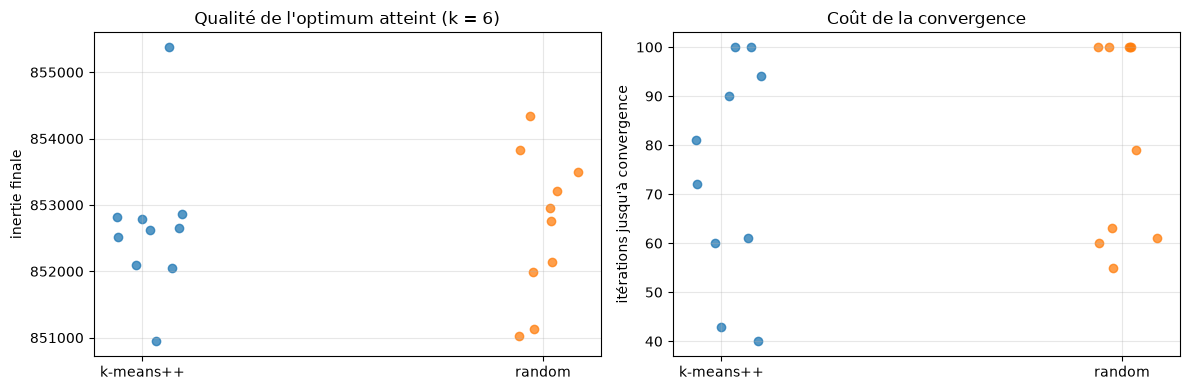

k-means++  | inertie moyenne =     852,676 | dispersion = 0.12% | itérations = 74.1
random     | inertie moyenne =     852,688 | dispersion = 0.12% | itérations = 81.8


In [6]:
# Deux inits, 10 graines chacune, n_init=1 pour isoler l'effet de l'initialisation
INIT_SEEDS = 10

if "init_study" in cache:
    init_study = cache["init_study"]
else:
    init_study = {}
    for init in ("k-means++", "random"):
        runs = [KMeans(n_clusters=6, n_init=1, max_iter=100, init=init, random_state=s).fit(X)
                for s in range(INIT_SEEDS)]
        init_study[init] = (np.array([m.inertia_ for m in runs]),
                            np.array([m.n_iter_ for m in runs]))
    cache["init_study"] = init_study
    save_cache(cache)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for i, (init, (inertias, iters)) in enumerate(init_study.items()):
    jitter = np.full(INIT_SEEDS, i) + rng.normal(0, 0.05, INIT_SEEDS)
    ax1.scatter(jitter, inertias, alpha=0.75)
    ax2.scatter(jitter, iters, alpha=0.75)

ax1.set_ylabel("inertie finale")
ax1.set_title("Qualité de l'optimum atteint (k = 6)")
ax2.set_ylabel("itérations jusqu'à convergence")
ax2.set_title("Coût de la convergence")
for ax in (ax1, ax2):
    ax.set_xticks([0, 1]); ax.set_xticklabels(list(init_study))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for init, (inertias, iters) in init_study.items():
    print(f"{init:10s} | inertie moyenne = {inertias.mean():11,.0f} | dispersion = {inertias.std() / inertias.mean():.2%}"
          f" | itérations = {iters.mean():4.1f}")

- Inertie finale identique entre les deux inits (écart moyen < 0.1%) et dispersion équivalente (~0.1%) : sur ces images, aucun bassin ne piège les départs uniformes.
- Seul gain mesurable : la convergence, ~74 itérations contre ~82.
- k-means++ paie quand des clusters bien séparés existent et qu'un tirage uniforme risque d'en rater un. Ici il n'y en a pas (cf. la silhouette plus bas), donc il n'a rien à corriger.

## 3. Projection et visualisation

### 3.1 Le dictionnaire à k = 6

- Chaque centroïde se réaffiche en image 32x32 RGB : les prototypes appris.
- Une couleur dominante et une tache centrale floue, la moyenne d'un cluster effaçant la forme précise.

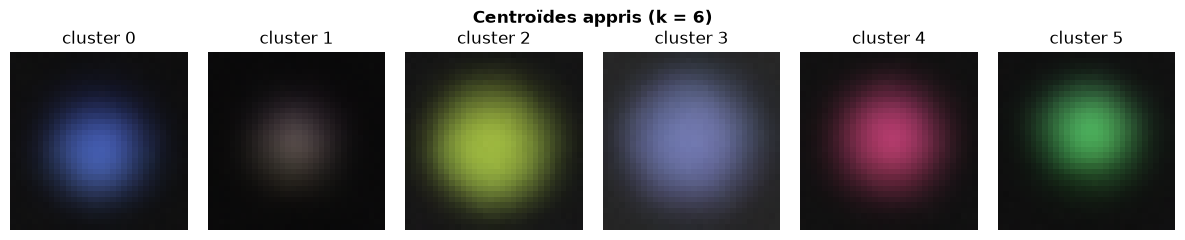

In [7]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for k, ax in enumerate(axes):
    ax.imshow(as_image(kmeans.centroids_[k]))
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Contenu des clusters

- Lignes +/- homogènes en couleur mais mélangeant les formes : le regroupement se fait surtout par teinte dominante, pas par géométrie.

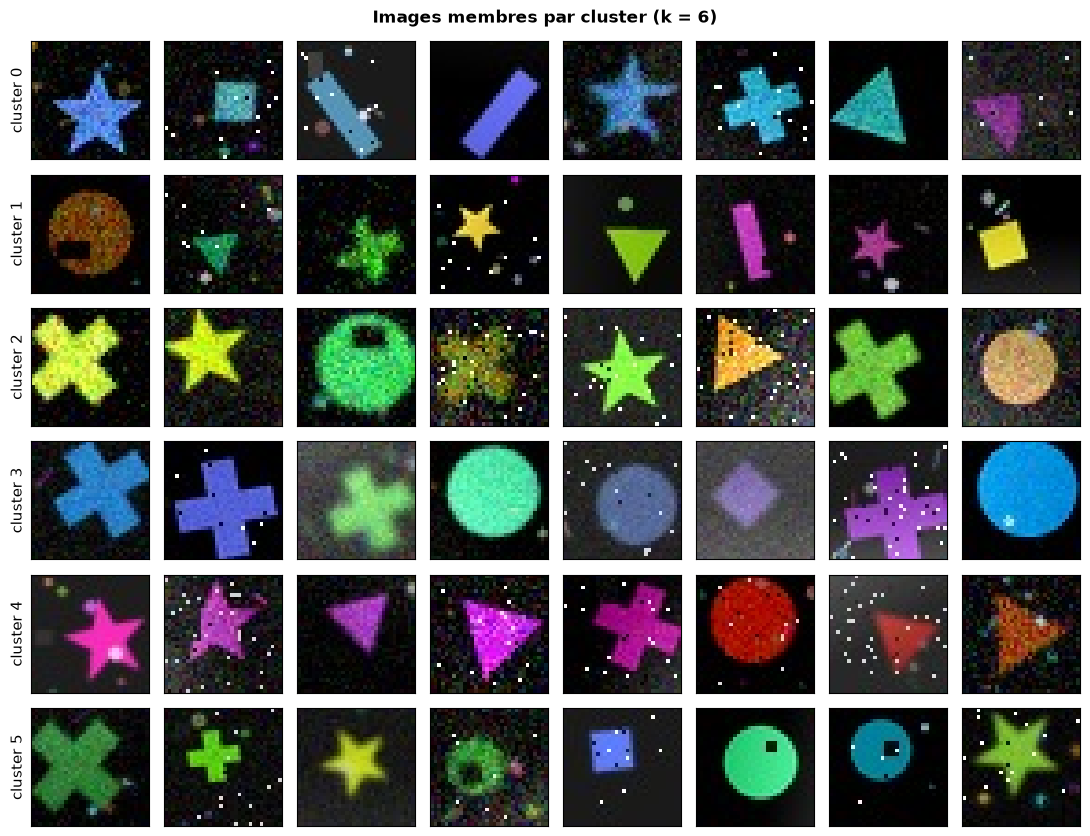

In [8]:
fig, axes = plt.subplots(6, 8, figsize=(11, 8.5))
for c in range(6):
    members = np.where(kmeans.labels_ == c)[0]
    picks = rng.choice(members, size=8, replace=False)
    for j in range(8):
        axes[c, j].imshow(as_image(X[picks[j]]))
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(f"cluster {c}", fontsize=11)
fig.suptitle("Images membres par cluster (k = 6)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Le dictionnaire à k = 64

- En montant K, le dictionnaire devient une palette de prototypes bien plus fine.
- Il couvre densément l'espace des couleurs mais reste presque partout des taches floues : K-Means dépense sa capacité à raffiner la couleur, pas la géométrie.

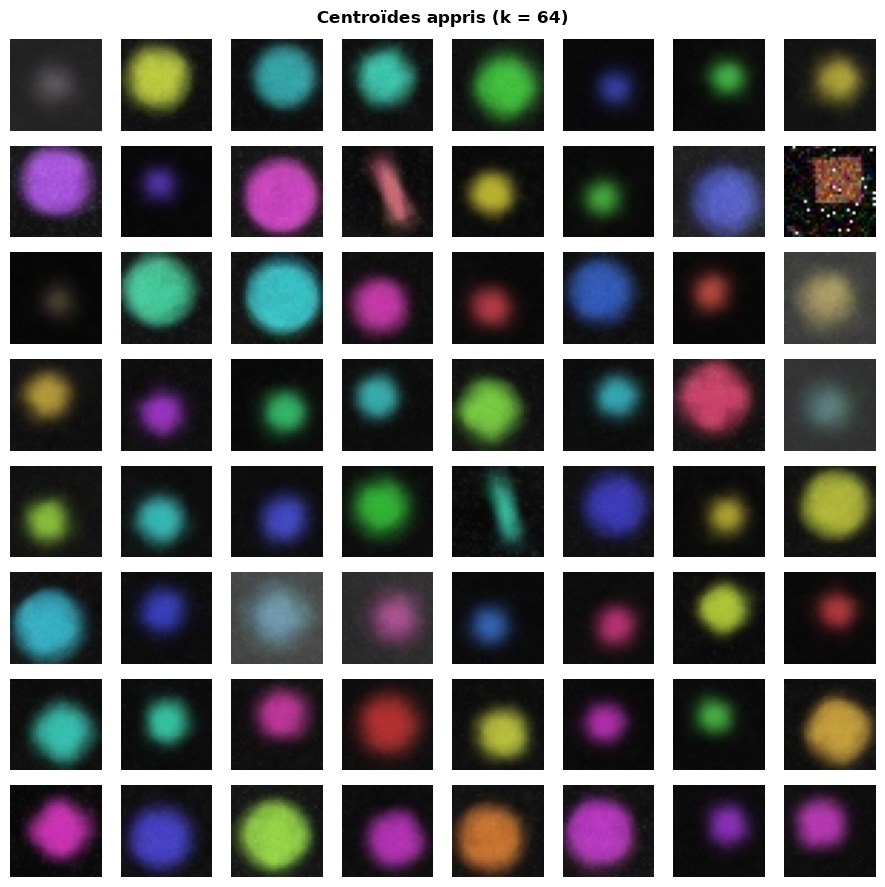

In [9]:
palette = models[64]
fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(as_image(palette.centroids_[k]))
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 64)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Combien d'images par cluster ?

- Taille de chaque cluster à k = 6, comparée à la répartition uniforme N / k.
- Puis selon K : l'entropie normalisée des tailles (1 = clusters égaux, 0 = tout dans un seul) et le nombre de clusters quasi vides.
- K-Means suppose des groupes de taille et de dispersion comparables ; l'écart à cette hypothèse se lit directement ici.

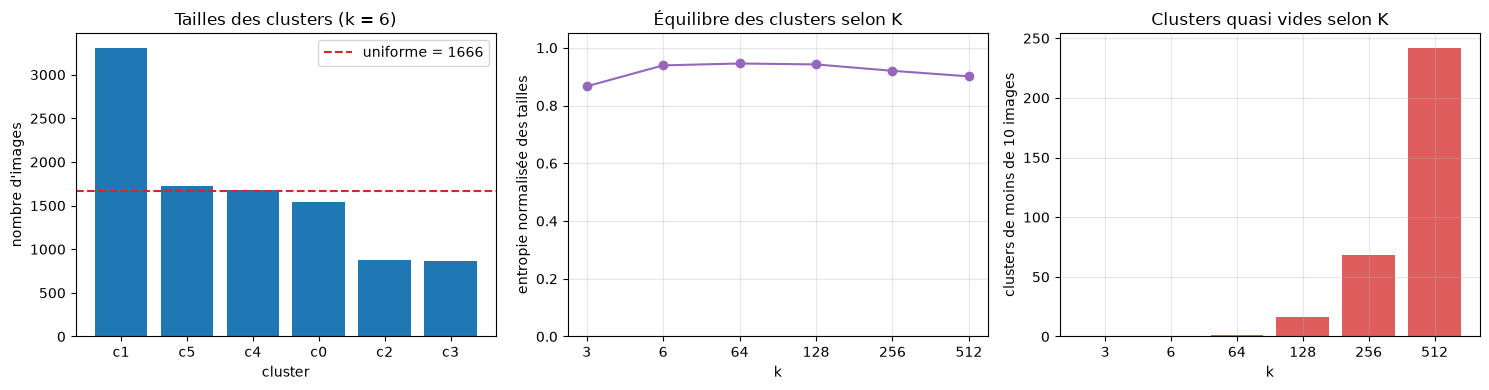

k =   3  ->  min = 2002  |  max =  5985  |  max/min =    3.0  |  clusters < 10 images =   0
k =   6  ->  min =  864  |  max =  3309  |  max/min =    3.8  |  clusters < 10 images =   0
k =  64  ->  min =    1  |  max =   458  |  max/min =  458.0  |  clusters < 10 images =   1
k = 128  ->  min =    1  |  max =   270  |  max/min =  270.0  |  clusters < 10 images =  16
k = 256  ->  min =    1  |  max =   176  |  max/min =  176.0  |  clusters < 10 images =  68
k = 512  ->  min =    1  |  max =   126  |  max/min =  126.0  |  clusters < 10 images = 242


In [10]:
sizes_main = np.bincount(kmeans.labels_, minlength=6)
order = np.argsort(sizes_main)[::-1]

# Entropie normalisée des tailles + clusters quasi vides, pour chaque K entraîné
entropies, tiny_counts = [], []
for k in K_VALUES:
    s = np.bincount(models[k].labels_, minlength=k)
    p = s[s > 0] / s.sum()
    entropies.append(-(p * np.log(p)).sum() / np.log(k))
    tiny_counts.append(int((s < 10).sum()))

pos = range(len(K_VALUES))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.bar(range(6), sizes_main[order], color="tab:blue")
ax1.axhline(N / 6, color="tab:red", linestyle="--", label=f"uniforme = {N // 6}")
ax1.set_xticks(range(6)); ax1.set_xticklabels([f"c{c}" for c in order])
ax1.set_xlabel("cluster"); ax1.set_ylabel("nombre d'images")
ax1.set_title("Tailles des clusters (k = 6)")
ax1.legend()

ax2.plot(pos, entropies, "o-", color="tab:purple")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("entropie normalisée des tailles")
ax2.set_title("Équilibre des clusters selon K")

ax3.bar(list(pos), tiny_counts, color="tab:red", alpha=0.75)
ax3.set_ylabel("clusters de moins de 10 images")
ax3.set_title("Clusters quasi vides selon K")

for ax in (ax2, ax3):
    ax.set_xlabel("k")
    ax.set_xticks(list(pos)); ax.set_xticklabels([str(k) for k in K_VALUES])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k in K_VALUES:
    s = np.bincount(models[k].labels_, minlength=k)
    print(f"k = {k:3d}  ->  min = {s.min():4d}  |  max = {s.max():5d}  |  max/min = {s.max() / max(s.min(), 1):6.1f}"
          f"  |  clusters < 10 images = {int((s < 10).sum()):3d}")

## 4. Compression et décompression

- On encode (chaque image devient un entier de cluster), puis on décode (chaque entier redevient son centroïde).
- `compression_report` mesure le poids du dictionnaire, celui des codes, et la MSE de reconstruction.
- À k = 6, gain énorme : un entier par image + six centroïdes partagés au lieu de 3072 flottants par image. En contrepartie, toutes les images d'un cluster se reconstruisent en une même tache, d'où une MSE élevée.

In [11]:
latent = kmeans.encode(X)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")

# codebook_bytes: 73728 = 6 × 3072 × 4 [octets (float32)]
# latent_bytes: 10000 = 10000 × 1 (uint8, K<=256)
# total_compressed_bytes: 83728 = 73728 + 10000
# original_bytes: 122880000 = 10000 × 3072 × 4 [octets (float32)]
# compression_ratio: 1467.6 = 122880000 / 83728
# reconstruction_mse: 0.0277 = MSE(original, reconstructed)

           latent_nature : discrete
          codebook_bytes : 73728
            latent_bytes : 10000
  total_compressed_bytes : 83728
          original_bytes : 122880000
       compression_ratio : 1467.6094018727308
      reconstruction_mse : 0.027703486382961273


### Effet de K sur la reconstruction et la compression

- Pour chaque K déjà entraîné, on mesure inertie, MSE, ratio de compression et précision forme.
- Monter K enrichit le dictionnaire : la MSE baisse (meilleure reconstruction) mais le ratio baisse aussi (le dictionnaire pèse plus lourd). C'est le compromis à arbitrer.
- Seuil de stockage du code discret : `latent_bytes` passe de 1 à 2 octets par image dès que K dépasse 256 (uint8 -> uint16), visible à k = 512.

In [12]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters, n_classes=6):
    """Label each cluster by its majority shape, then score the induced classifier."""
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=n_classes).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


sweep = []
for k in K_VALUES:
    model = models[k]
    lat = model.encode(X)
    rep = compression_report(model.get_codebook(), lat, X, model.decode(lat))
    acc, _ = majority_vote_accuracy(model.labels_, y, k)
    sweep.append((k, model.inertia_, rep["reconstruction_mse"], rep["compression_ratio"], acc))
    print(f"k = {k:3d}  ->  inertie = {model.inertia_:11,.0f}  |  MSE = {rep['reconstruction_mse']:.5f}"
          f"  |  ratio = {rep['compression_ratio']:8.1f}  |  précision forme = {acc:.2%}")

k =   3  ->  inertie =     924,911  |  MSE = 0.03011  |  ratio =   2622.1  |  précision forme = 26.10%


k =   6  ->  inertie =     851,051  |  MSE = 0.02770  |  ratio =   1467.6  |  précision forme = 26.29%


k =  64  ->  inertie =     625,391  |  MSE = 0.02036  |  ratio =    154.3  |  précision forme = 31.52%


k = 128  ->  inertie =     584,699  |  MSE = 0.01903  |  ratio =     77.6  |  précision forme = 35.56%


k = 256  ->  inertie =     545,872  |  MSE = 0.01777  |  ratio =     38.9  |  précision forme = 38.98%


k = 512  ->  inertie =     501,963  |  MSE = 0.01634  |  ratio =     19.5  |  précision forme = 43.50%


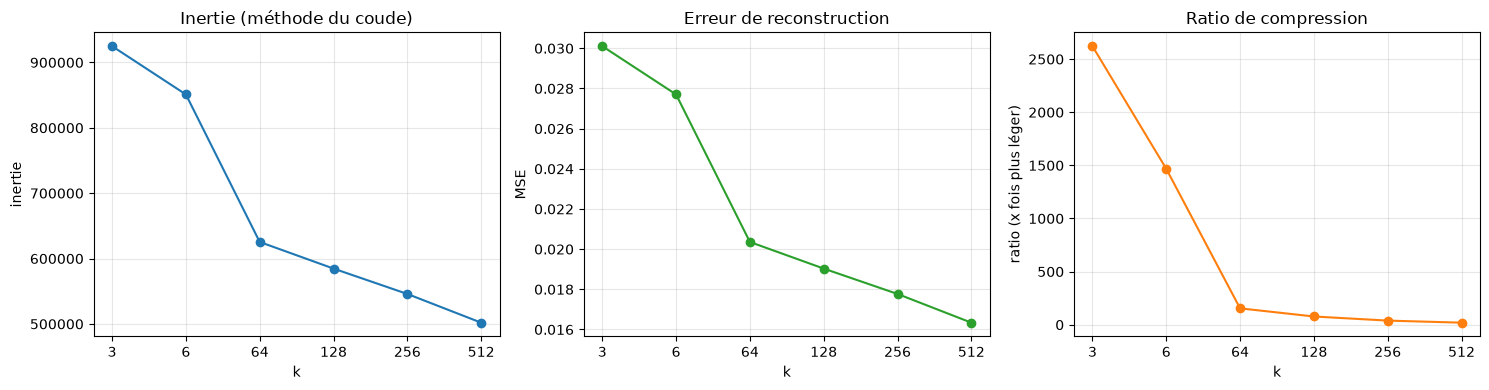

In [13]:
ks = [r[0] for r in sweep]
inertias = [r[1] for r in sweep]
mses = [r[2] for r in sweep]
ratios = [r[3] for r in sweep]

# k réparti uniformément sur l'axe pour rester lisible (les valeurs vont de 3 à 512)
pos = range(len(ks))
labels_k = [str(k) for k in ks]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
ax1.plot(pos, inertias, "o-")
ax1.set_title("Inertie (méthode du coude)")
ax1.set_xlabel("k"); ax1.set_ylabel("inertie")

ax2.plot(pos, mses, "o-", color="tab:green")
ax2.set_title("Erreur de reconstruction")
ax2.set_xlabel("k"); ax2.set_ylabel("MSE")

ax3.plot(pos, ratios, "o-", color="tab:orange")
ax3.set_title("Ratio de compression")
ax3.set_xlabel("k"); ax3.set_ylabel("ratio (x fois plus léger)")

for ax in (ax1, ax2, ax3):
    ax.set_xticks(list(pos)); ax.set_xticklabels(labels_k)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Quel K choisir sans étiquettes ?

- La courbe d'inertie ci-dessus décroît sans coude franc : la méthode du coude ne tranche pas.
- Second critère, toujours sans étiquettes : le coefficient de silhouette. Pour chaque point, `(b - a) / max(a, b)` avec `a` la distance moyenne aux points de son cluster et `b` la distance moyenne au cluster voisin le plus proche ; on moyenne sur les points.
- Proche de 1 : clusters compacts et bien séparés. Proche de 0 : les clusters se touchent, pas de structure. Négatif : points du mauvais côté de la frontière.
- `silhouette_score` coûte O(n²) : on sous-échantillonne. Un tirage unique ne départage pas des K voisins (l'écart entre eux est du même ordre que le bruit d'échantillonnage), donc on moyenne sur 5 tirages de 3000 images et on affiche l'écart-type.
- Plage k = 2..20, avec des réglages allégés (`n_init=3`, `max_iter=50`) propres à cette étude.

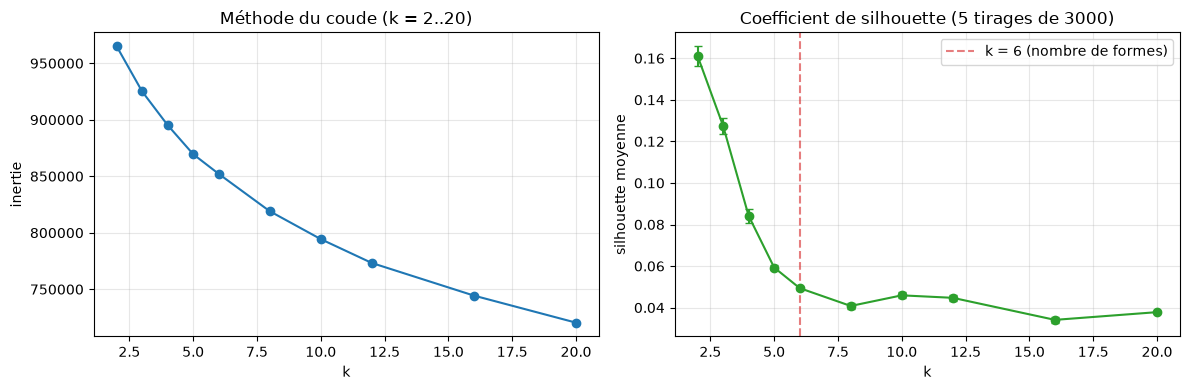

k =  2  ->  silhouette = 0.1611 +/- 0.0047
k =  3  ->  silhouette = 0.1274 +/- 0.0040
k =  4  ->  silhouette = 0.0842 +/- 0.0035
k =  5  ->  silhouette = 0.0593 +/- 0.0012
k =  6  ->  silhouette = 0.0494 +/- 0.0007
k =  8  ->  silhouette = 0.0408 +/- 0.0013
k = 10  ->  silhouette = 0.0459 +/- 0.0014
k = 12  ->  silhouette = 0.0447 +/- 0.0015
k = 16  ->  silhouette = 0.0341 +/- 0.0013
k = 20  ->  silhouette = 0.0378 +/- 0.0005

Meilleur k hors k = 2 : k = 3


In [14]:
from sklearn.metrics import silhouette_score

SIL_K = [2, 3, 4, 5, 6, 8, 10, 12, 16, 20]
SIL_SUB, SIL_REP = 3000, 5

small_models = cache.get("small_models", {})
for k in SIL_K:
    if k not in small_models:
        small_models[k] = KMeans(n_clusters=k, n_init=3, max_iter=50, random_state=0).fit(X)
cache["small_models"] = small_models
save_cache(cache)

# Moyenne sur SIL_REP sous-échantillons : un tirage unique ne départage pas les K voisins
sil_mean, sil_std = [], []
for k in SIL_K:
    scores = []
    for r in range(SIL_REP):
        idx = np.random.default_rng(100 + r).choice(N, size=SIL_SUB, replace=False)
        scores.append(silhouette_score(X[idx], small_models[k].labels_[idx]))
    sil_mean.append(np.mean(scores))
    sil_std.append(np.std(scores))

sil_inertias = [small_models[k].inertia_ for k in SIL_K]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(SIL_K, sil_inertias, "o-")
ax1.set_ylabel("inertie")
ax1.set_title("Méthode du coude (k = 2..20)")

ax2.errorbar(SIL_K, sil_mean, yerr=sil_std, fmt="o-", color="tab:green", capsize=3)
ax2.axvline(6, color="tab:red", linestyle="--", alpha=0.6, label="k = 6 (nombre de formes)")
ax2.set_ylabel("silhouette moyenne")
ax2.set_title("Coefficient de silhouette ({} tirages de {})".format(SIL_REP, SIL_SUB))
ax2.legend()

for ax in (ax1, ax2):
    ax.set_xlabel("k"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k, m, s in zip(SIL_K, sil_mean, sil_std):
    print(f"k = {k:2d}  ->  silhouette = {m:.4f} +/- {s:.4f}")

# k = 2 est une partition dégénérée, on regarde le meilleur K au-delà
cand = [(k, m) for k, m in zip(SIL_K, sil_mean) if k != 2]
print(f"\nMeilleur k hors k = 2 : k = {max(cand, key=lambda t: t[1])[0]}")

- Décroissance monotone à partir de k = 2, **aucune bosse à k = 6** : rien ne signale les six formes. Le meilleur k hors k = 2 est k = 3, sur tous les tirages.
- Valeurs qui s'écrasent vers 0 (~0.05 à k = 6, ~0.03 à k = 20) : les clusters se touchent, il n'y a pas de structure euclidienne à trouver.
- Les deux critères sans étiquettes concordent avec la précision proche du hasard : le problème n'est pas le choix de K, c'est la représentation.

### Reconstruction selon K

- Mêmes images reconstruites par chaque dictionnaire : une ligne d'originaux, une ligne par K.
- À petit K, chaque image se réduit à une tache colorée ; en montant K la couleur devient fidèle et quelques formes se devinent, la plupart restant des taches.

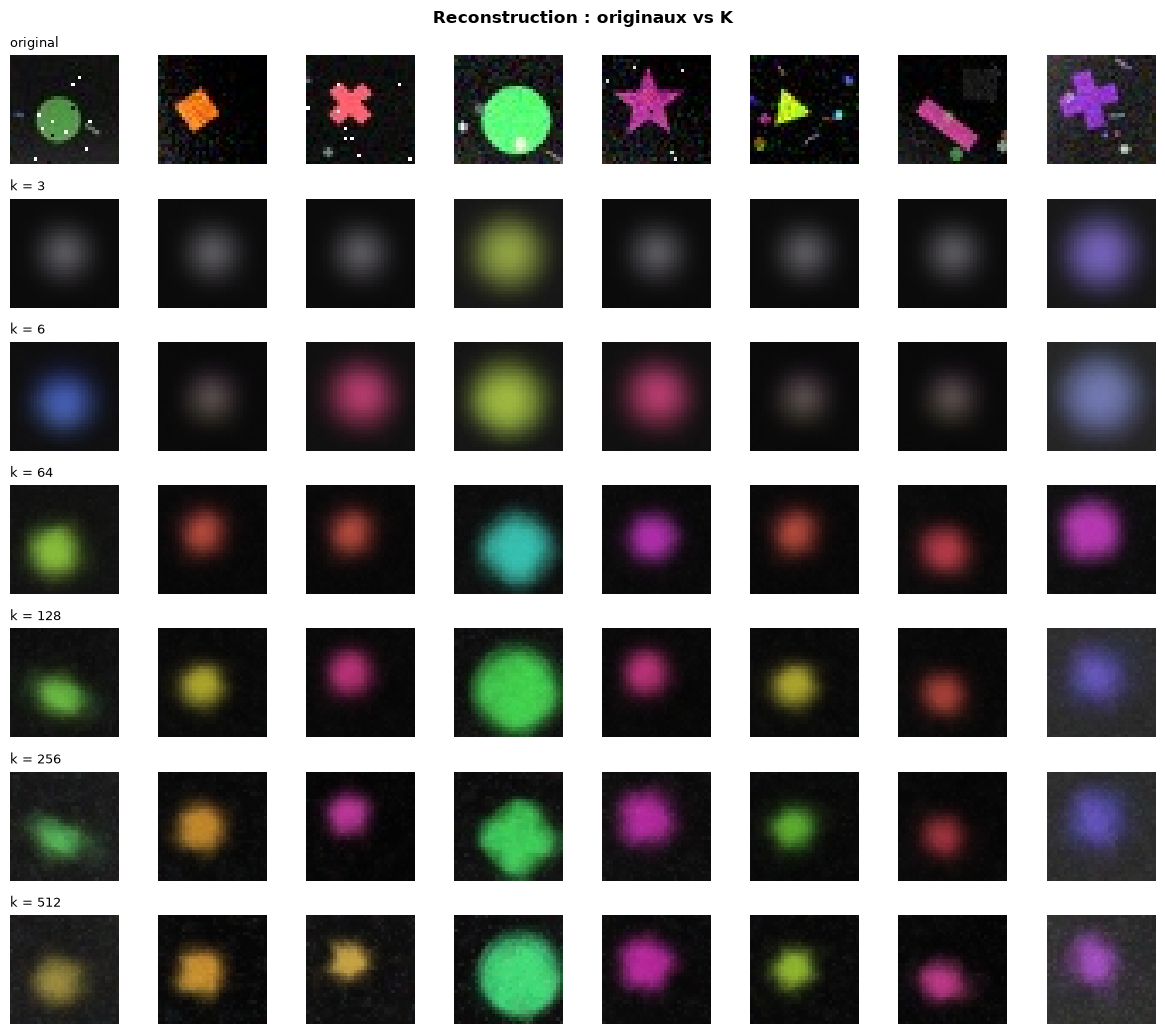

In [15]:
sample_idx = rng.choice(N, size=8, replace=False)

rows = [("original", X[sample_idx])]
for k in K_VALUES:
    model = models[k]
    rows.append((f"k = {k}", model.decode(model.encode(X[sample_idx]))))

fig, axes = plt.subplots(len(rows), 8, figsize=(12, 1.5 * len(rows)))
for r, (label, imgs) in enumerate(rows):
    for c in range(8):
        axes[r, c].imshow(as_image(imgs[c]))
        axes[r, c].axis("off")
    axes[r, 0].set_title(label, fontsize=9, loc="left")
fig.suptitle("Reconstruction : originaux vs K", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Les clusters correspondent-ils aux formes ?

- K-Means ignore les étiquettes ; on regarde a posteriori le lien avec les formes.
- Chaque cluster reçoit sa forme majoritaire ; la pureté d'un cluster = part de cette forme dominante.
- La précision par vote majoritaire est la moyenne de ces parts, pondérée par la taille des clusters (colonne "précision forme" de la table du balayage ci-dessus).

### Vote majoritaire et pureté à k = 6

- Précision par vote majoritaire, puis pour chaque cluster sa forme dominante, sa pureté et sa taille.
- La table de contingence qui suit croise clusters et formes réelles.

In [16]:
acc, mapping = majority_vote_accuracy(kmeans.labels_, y, 6)
print(f"Précision par vote majoritaire (forme, k = 6) : {acc:.2%}")
print(f"Niveau du hasard (6 formes équilibrées)       : {1 / 6:.2%}\n")
for c in range(6):
    counts = np.bincount(y[kmeans.labels_ == c], minlength=6)
    purity = counts.max() / counts.sum()
    print(f"cluster {c}: forme dominante = {class_names[mapping[c]]:>8}  |  pureté = {purity:5.1%}  |  taille = {counts.sum()}")

Précision par vote majoritaire (forme, k = 6) : 26.29%
Niveau du hasard (6 formes équilibrées)       : 16.67%

cluster 0: forme dominante =    cross  |  pureté = 19.5%  |  taille = 1545
cluster 1: forme dominante =      bar  |  pureté = 28.2%  |  taille = 3309
cluster 2: forme dominante =   circle  |  pureté = 38.0%  |  taille = 879
cluster 3: forme dominante =   circle  |  pureté = 42.2%  |  taille = 864
cluster 4: forme dominante =   circle  |  pureté = 22.0%  |  taille = 1678
cluster 5: forme dominante =     star  |  pureté = 19.0%  |  taille = 1725


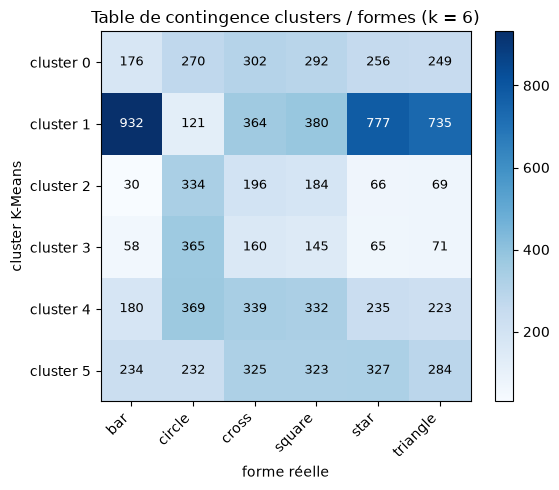

In [17]:
contingency = np.zeros((6, 6), dtype=int)
for c in range(6):
    contingency[c] = np.bincount(y[kmeans.labels_ == c], minlength=6)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contingency, cmap="Blues")
ax.set_xticks(range(6)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(6)); ax.set_yticklabels([f"cluster {c}" for c in range(6)])
ax.set_xlabel("forme réelle"); ax.set_ylabel("cluster K-Means")
for c in range(6):
    for s in range(6):
        ax.text(s, c, contingency[c, s], ha="center", va="center",
                color="white" if contingency[c, s] > contingency.max() / 2 else "black", fontsize=9)
ax.set_title("Table de contingence clusters / formes (k = 6)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

- Précision proche du hasard, progression lente avec K : les clusters supplémentaires raffinent surtout couleur et position, pas la forme.
- Sur pixels bruts RGB, la distance euclidienne est dominée par la couleur puis la pose ; séparer les formes demanderait une représentation invariante à ces deux facteurs.

## 6. Génération de données

- Vu comme modèle génératif, K-Means définit une loi a priori sur les codes : une catégorielle sur les K indices de cluster, estimée par les fréquences d'assignation.
- Générer = tirer un indice selon cette loi, puis renvoyer son centroïde (décodage déterministe).
- Support de la loi = exactement les K centroïdes : aucune image hors dictionnaire.
- On compare k = 6 et k = 64 pour voir le vocabulaire s'enrichir.

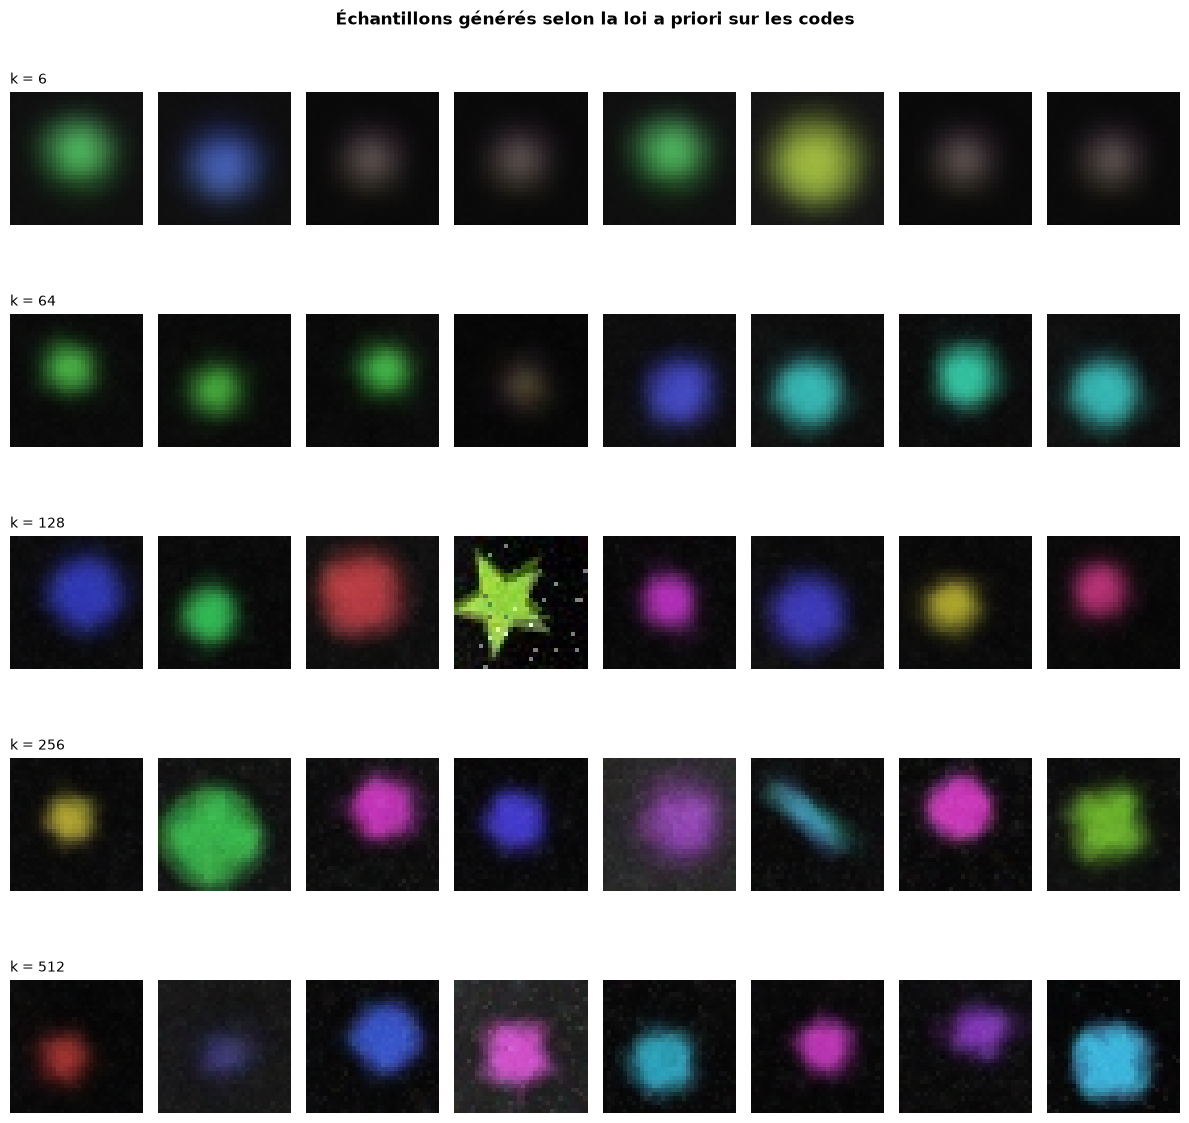

In [18]:
def sample_from(model, n_samples):
    """Draw cluster codes from the empirical assignment frequencies, decode to centroids."""
    prior = np.bincount(model.labels_, minlength=model.n_clusters) / len(model.labels_)
    codes = Latent(array=rng.choice(model.n_clusters, size=n_samples, p=prior), nature="discrete")
    return codes.array, model.decode(codes)


fig, axes = plt.subplots(5, 8, figsize=(12, 12))
for row, model in enumerate([models[6], models[64], models[128], models[256], models[512]]):
    codes, gen = sample_from(model, 8)
    for col in range(8):
        axes[row, col].imshow(as_image(gen[col]))
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"k = {model.n_clusters}", fontsize=10, loc="left")
fig.suptitle("Échantillons générés selon la loi a priori sur les codes", fontweight="bold")
plt.tight_layout()
plt.show()